# PeeringDB Coverage Bias Analysis

Verifies the claim:

> *PeeringDB coverage is positively correlated with node degree: the ASes most likely
> to have PeeringDB records are precisely those that are already well-characterized by
> structural features. For smaller stub ASes — which represent the majority of the graph
> but contribute a minority of traffic — PeeringDB attributes are frequently absent.*

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

DATA = Path('/media/vale/KINGSTON/TESIS/data_2026')
nodes_file = DATA / 'nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
edges_file = DATA / 'edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'

nodes_df = pd.read_csv(nodes_file)
edges_df = pd.read_csv(edges_file)
print(f"Nodes: {len(nodes_df):,}   Edges: {len(edges_df):,}")

Nodes: 79,504   Edges: 734,381


In [2]:
# ── Column classification ─────────────────────────────────────
TOPO_COLS = ['weight', 'degree_centrality', 'betweenness_centrality',
             'eigenvector_centrality', 'PageRank']
META_COLS  = ['node_id', 'asn']

# PeeringDB categorical groups and their "Unknown / Not Disclosed" markers
PEERINGDB_GROUPS = {
    'policy_general':   ['policy_general_No','policy_general_Open',
                         'policy_general_Restrictive','policy_general_Selective',
                         'policy_general_Unknown'],
    'policy_locations': [c for c in nodes_df.columns if c.startswith('policy_locations_')],
    'policy_contracts': [c for c in nodes_df.columns if c.startswith('policy_contracts_')],
    'info_traffic':     [c for c in nodes_df.columns if c.startswith('info_traffic_')],
    'info_scope':       [c for c in nodes_df.columns if c.startswith('info_scope_')],
    'info_type':        [c for c in nodes_df.columns if c.startswith('info_type_')],
    'info_ratio':       [c for c in nodes_df.columns if c.startswith('info_ratio_')],
}
UNKNOWN_MARKERS = {g: [c for c in cols if 'Unknown' in c or 'Not Disclosed' in c]
                   for g, cols in PEERINGDB_GROUPS.items()}

PEERINGDB_NUMERIC = ['ix_count', 'fac_count', 'info_prefixes4', 'info_prefixes6']
PEERINGDB_NUMERIC = [c for c in PEERINGDB_NUMERIC if c in nodes_df.columns]

print("PeeringDB numeric features:", PEERINGDB_NUMERIC)
print("PeeringDB categorical groups:", list(PEERINGDB_GROUPS.keys()))

PeeringDB numeric features: ['ix_count', 'fac_count', 'info_prefixes4', 'info_prefixes6']
PeeringDB categorical groups: ['policy_general', 'policy_locations', 'policy_contracts', 'info_traffic', 'info_scope', 'info_type', 'info_ratio']


In [3]:
# ── Per-node PeeringDB richness score ─────────────────────────
# Each component in [0, 1]; overall score = mean across components.

df = nodes_df.copy()

# 1. Numeric: any record at all (ix_count or fac_count > 0 = registered AS)
df['has_numeric']   = (df[PEERINGDB_NUMERIC] > 0).any(axis=1).astype(float)
df['has_ixp']       = (df['ix_count']  > 0).astype(int) if 'ix_count'  in df.columns else 0
df['has_facility']  = (df['fac_count'] > 0).astype(int) if 'fac_count' in df.columns else 0

# 2. Categorical: 1 if group is NOT unknown/not-disclosed, 0 otherwise
for grp, cols in PEERINGDB_GROUPS.items():
    unk_cols   = UNKNOWN_MARKERS[grp]
    known_cols = [c for c in cols if c not in unk_cols]
    if known_cols:
        df[f'known_{grp}'] = (df[known_cols].sum(axis=1) > 0).astype(float)
    else:
        df[f'known_{grp}'] = 0.0

score_cols = ['has_numeric'] + [f'known_{g}' for g in PEERINGDB_GROUPS]
df['pdb_score'] = df[score_cols].mean(axis=1)   # 0 = no PeeringDB, 1 = fully covered

# Degree from edges (undirected: count each node as src or dst)
deg = (pd.concat([edges_df['src_id'].rename('node_id'),
                  edges_df['dst_id'].rename('node_id')])
         .value_counts()
         .reset_index(name='degree'))
df = df.merge(deg, on='node_id', how='left')
df['degree'] = df['degree'].fillna(0).astype(int)

print(f"Nodes with pdb_score = 0  (no PeeringDB data) : {(df['pdb_score']==0).sum():>7,}  "
      f"({(df['pdb_score']==0).mean()*100:.1f}%)")
print(f"Nodes with pdb_score = 1  (fully covered)     : {(df['pdb_score']==1).sum():>7,}  "
      f"({(df['pdb_score']==1).mean()*100:.1f}%)")
print(f"\nDegree stats:")
print(df['degree'].describe().round(1).to_string())

Nodes with pdb_score = 0  (no PeeringDB data) :  53,041  (66.7%)
Nodes with pdb_score = 1  (fully covered)     :  13,530  (17.0%)

Degree stats:
count    79504.0
mean        18.5
std        201.0
min          1.0
25%          2.0
50%          4.0
75%          7.0
max      19619.0


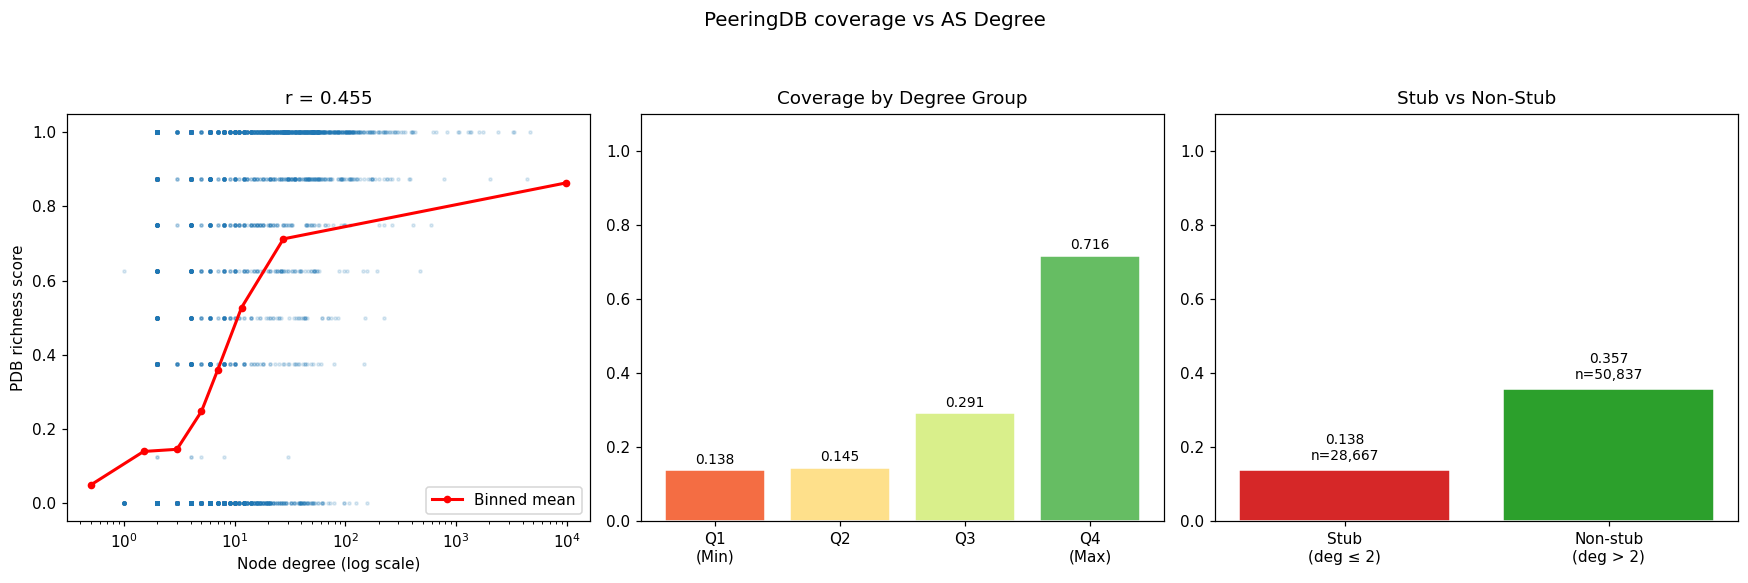

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os

# 1. Correlación
rho, pval = spearmanr(df['degree'], df['pdb_score'])
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel A: Scatter con Bins ---
ax = axes[0]
sample = df.sample(min(8000, len(df)), random_state=42)
ax.scatter(sample['degree'], sample['pdb_score'], alpha=0.15, s=4, color='#1F77B4', rasterized=True)

# Bins logarítmicos automáticos
b_edges = np.unique(np.percentile(df['degree'][df['degree']>0], np.linspace(0, 100, 15)).astype(int))
df['deg_bin'] = pd.cut(df['degree'], bins=np.unique(np.insert(b_edges, 0, 0)))
binned = df.groupby('deg_bin', observed=True)['pdb_score'].mean()
bin_centers = [i.mid for i in binned.index]

ax.plot(bin_centers, binned.values, color='red', lw=2, marker='o', markersize=4, label='Binned mean')
ax.set_xscale('log')
ax.set_xlabel('Node degree (log scale)')
ax.set_ylabel('PDB richness score')
ax.set_title(f'r = {rho:.3f}')
ax.set_ylim(-0.05, 1.05)
ax.legend()

# --- Panel B: Quintiles (DINÁMICO PARA EVITAR TU ERROR) ---
ax = axes[1]

# retbins=True nos dice cuántos bordes encontró realmente
_, found_bins = pd.qcut(df['degree'], q=5, duplicates='drop', retbins=True)
n_bins_actual = len(found_bins) - 1

# Generamos etiquetas según la cantidad real de bins
dynamic_labels = [f'Q{i+1}' for i in range(n_bins_actual)]
if n_bins_actual > 0:
    dynamic_labels[0] += '\n(Min)'
    dynamic_labels[-1] += '\n(Max)'

# Aplicamos qcut con las etiquetas calculadas
df['degree_quintile'] = pd.qcut(df['degree'], q=5, labels=dynamic_labels, duplicates='drop')
q_means = df.groupby('degree_quintile', observed=True)['pdb_score'].mean()

bars = ax.bar(q_means.index.astype(str), q_means.values,
              color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(q_means))),
              edgecolor='white')

for b, v in zip(bars, q_means.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Coverage by Degree Group')
ax.set_ylim(0, 1.1)

# --- Panel C: Stub vs Non-Stub ---
ax = axes[2]
df['is_stub'] = df['degree'] <= 2
stats = df.groupby('is_stub')['pdb_score'].agg(['mean', 'count'])

labels = ['Stub\n(deg ≤ 2)', 'Non-stub\n(deg > 2)']
values = [stats.loc[True, 'mean'], stats.loc[False, 'mean']]
counts = [stats.loc[True, 'count'], stats.loc[False, 'count']]

bars = ax.bar(labels, values, color=['#D62728', '#2CA02C'], edgecolor='white')
for b, v, n in zip(bars, values, counts):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}\nn={n:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('Stub vs Non-Stub')
ax.set_ylim(0, 1.1)

plt.suptitle('PeeringDB coverage vs AS Degree', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('results/pdb_coverage_vs_degree.pdf', bbox_inches='tight')
plt.show()

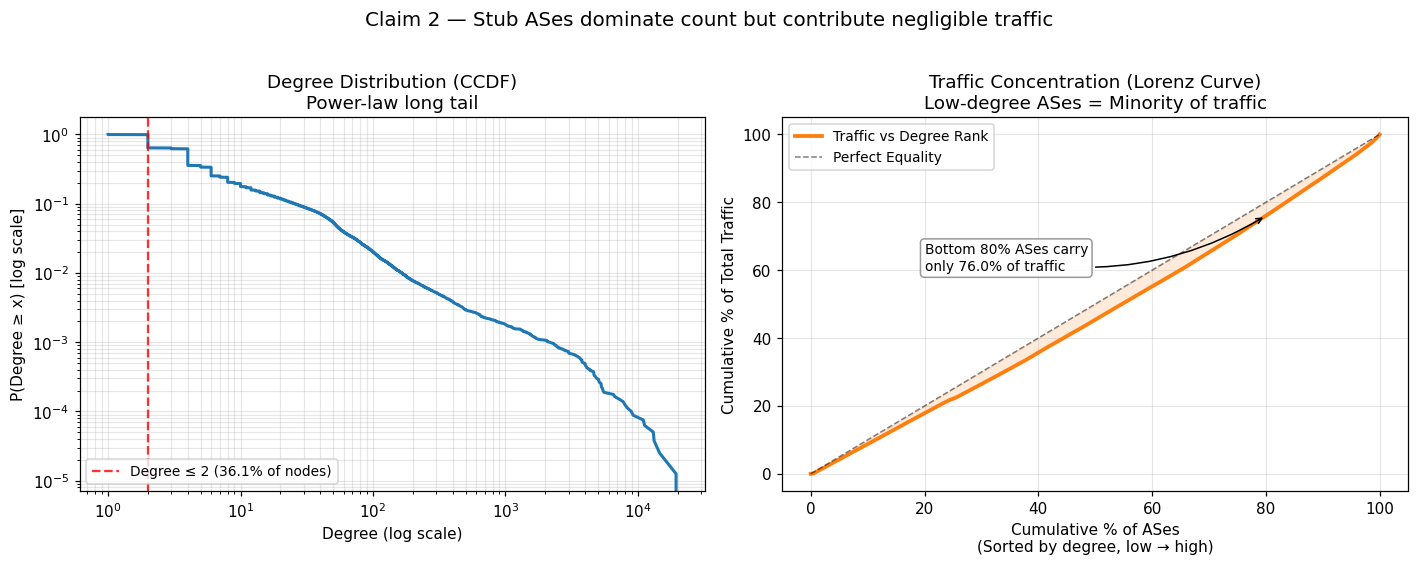


--- Resumen de la Estructura de la Red ---
Total de ASes analizados: 79,504
Stub ASes (degree ≤ 2)  : 28,667 (36.1% del total)
Participación de tráfico: 31.93% del tráfico total
Conclusión: El 63.9% de los ASes (Core) mueve el 68.07% del tráfico.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Asegurar que la carpeta existe
os.makedirs('results', exist_ok=True)

# Limpieza previa: trabajamos con una copia para no alterar el DF original
# Filtramos grados > 0 y manejamos NaNs en weight
plot_df = df[df['degree'] > 0].copy()
plot_df['weight'] = plot_df['weight'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: CCDF de Grado (Distribución de larga cola) ---
ax = axes[0]
deg_values = plot_df['degree'].values
deg_sorted = np.sort(deg_values)
# El CCDF se calcula como 1 - F(x)
ccdf = 1.0 - np.arange(1, len(deg_sorted) + 1) / len(deg_sorted)

# Graficamos en escala log-log para ver la ley de potencia (línea recta)
ax.loglog(deg_sorted, ccdf, color='#1F77B4', lw=2)

ax.set_xlabel('Degree (log scale)')
ax.set_ylabel('P(Degree ≥ x) [log scale]')
ax.set_title('Degree Distribution (CCDF)\nPower-law long tail')
ax.grid(True, which='both', alpha=0.3)

# Anotación de Stubs (Grado <= 2)
stub_mask = plot_df['degree'] <= 2
stub_frac = stub_mask.mean()
ax.axvline(2, color='red', linestyle='--', lw=1.5, alpha=0.8,
           label=f'Degree ≤ 2 ({stub_frac*100:.1f}% of nodes)')
ax.legend(fontsize=9, loc='lower left')

# --- Panel 2: Curva de Lorenz (Concentración de Tráfico/Weight) ---
ax = axes[1]
# Ordenamos por grado de menor a mayor
df_sorted = plot_df.sort_values('degree')

# Eje X: Porcentaje acumulado de nodos
cum_nodes = np.linspace(0, 100, len(df_sorted))

# Eje Y: Porcentaje acumulado de tráfico
cum_weight = df_sorted['weight'].cumsum() / df_sorted['weight'].sum() * 100

ax.plot(cum_nodes, cum_weight, color='#FF7F0E', lw=2.5, label='Traffic vs Degree Rank')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, lw=1, label='Perfect Equality')

ax.set_xlabel('Cumulative % of ASes\n(Sorted by degree, low → high)')
ax.set_ylabel('Cumulative % of Total Traffic')
ax.set_title('Traffic Concentration (Lorenz Curve)\nLow-degree ASes = Minority of traffic')

# Rellenar el área de desigualdad
ax.fill_between(cum_nodes, cum_nodes, cum_weight, alpha=0.15, color='#FF7F0E')

# Anotación dinámica del punto 80%
idx_80 = np.abs(cum_nodes - 80).argmin()
traffic_at_80 = cum_weight.iloc[idx_80]

ax.annotate(f'Bottom 80% ASes carry\nonly {traffic_at_80:.1f}% of traffic',
            xy=(80, traffic_at_80), xytext=(20, 60),
            arrowprops=dict(arrowstyle='->', color='black', connectionstyle="arc3,rad=.2"),
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Claim 2 — Stub ASes dominate count but contribute negligible traffic',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/pdb_long_tail.pdf', bbox_inches='tight')
plt.show()

# --- Estadísticas en consola ---
total_nodes = len(df)
stubs = df[df['degree'] <= 2]
stub_count = len(stubs)
stub_perc = (stub_count / total_nodes) * 100
traffic_share = (stubs['weight'].sum() / df['weight'].sum()) * 100

print(f"\n--- Resumen de la Estructura de la Red ---")
print(f"Total de ASes analizados: {total_nodes:,}")
print(f"Stub ASes (degree ≤ 2)  : {stub_count:,} ({stub_perc:.1f}% del total)")
print(f"Participación de tráfico: {traffic_share:.2f}% del tráfico total")
print(f"Conclusión: El {100-stub_perc:.1f}% de los ASes (Core) mueve el {100-traffic_share:.2f}% del tráfico.")

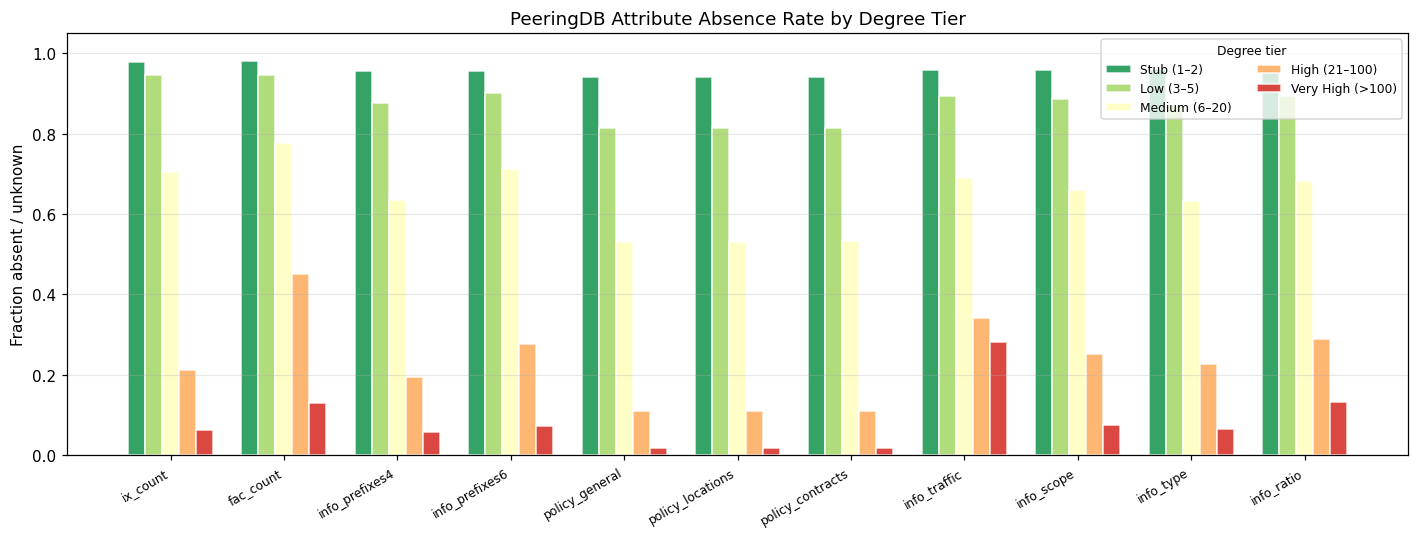

In [6]:
# ── Claim 3: null rate per PeeringDB attribute by degree tier ─
df['degree_tier'] = pd.cut(df['degree'],
    bins=[-1, 1, 5, 20, 100, np.inf],
    labels=['Stub\n(1–2)', 'Low\n(3–5)', 'Medium\n(6–20)',
            'High\n(21–100)', 'Very High\n(>100)'])

# "Absent" for numeric = 0; for categorical = Unknown selected
absent_cols = {}
for num in PEERINGDB_NUMERIC:
    absent_cols[num] = (df[num] == 0).astype(float)
for grp, unk_list in UNKNOWN_MARKERS.items():
    if unk_list:
        absent_cols[grp] = df[unk_list].max(axis=1)

absent_df = pd.DataFrame(absent_cols, index=df.index)
absent_df['degree_tier'] = df['degree_tier']

tier_absent = (absent_df.groupby('degree_tier', observed=True)
                         .mean()
                         .drop(columns=['degree_tier'], errors='ignore'))

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(tier_absent.columns))
width = 0.15
tiers = tier_absent.index.tolist()
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(tiers)))

for i, (tier, color) in enumerate(zip(tiers, colors)):
    ax.bar(x + i*width, tier_absent.loc[tier], width,
           label=tier.replace('\n',' '), color=color, alpha=0.88, edgecolor='white')

ax.set_xticks(x + width*(len(tiers)-1)/2)
ax.set_xticklabels(tier_absent.columns, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Fraction absent / unknown')
ax.set_title('PeeringDB Attribute Absence Rate by Degree Tier')
ax.set_ylim(0, 1.05)
ax.legend(title='Degree tier', fontsize=8, title_fontsize=8,
          loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/pdb_absence_by_tier.pdf', bbox_inches='tight')
plt.show()

In [7]:
# ── Summary — numbers to cite in the paper ───────────────────
print("=" * 65)
print("PEERINGDB COVERAGE BIAS — KEY STATISTICS")
print("=" * 65)

rho, pval = spearmanr(df['degree'], df['pdb_score'])
print(f"\nCorrelation (Spearman r):  {rho:.4f}  (p={pval:.1e})")

for tier in df['degree_tier'].cat.categories:
    sub = df[df['degree_tier']==tier]
    print(f"  {str(tier).replace(chr(10),' '):<22}  "
          f"n={len(sub):>6,}  ({len(sub)/len(df)*100:4.1f}%)  "
          f"mean_coverage={sub['pdb_score'].mean():.3f}  "
          f"traffic_share={sub['weight'].sum()/df['weight'].sum()*100:5.2f}%")

stub_mask = df['degree_tier'] == 'Stub\n(1–2)'
print(f"\nStub ASes (degree 1-2):")
print(f"  Count      : {stub_mask.sum():,} ({stub_mask.mean()*100:.1f}% of all ASes)")
print(f"  Coverage   : {df[stub_mask]['pdb_score'].mean():.3f} (graph avg: {df['pdb_score'].mean():.3f})")
print(f"  Traffic    : {df[stub_mask]['weight'].sum()/df['weight'].sum()*100:.2f}% of total")

print(f"\nTop-degree ASes (degree > 100):")
top_mask = df['degree'] > 100
print(f"  Count      : {top_mask.sum():,} ({top_mask.mean()*100:.2f}% of all ASes)")
print(f"  Coverage   : {df[top_mask]['pdb_score'].mean():.3f}")
print(f"  Traffic    : {df[top_mask]['weight'].sum()/df['weight'].sum()*100:.2f}% of total")
print("=" * 65)

PEERINGDB COVERAGE BIAS — KEY STATISTICS

Correlation (Spearman r):  0.4549  (p=0.0e+00)
  Stub (1–2)              n=   311  ( 0.4%)  mean_coverage=0.049  traffic_share= 0.06%
  Low (3–5)               n=52,385  (65.9%)  mean_coverage=0.144  traffic_share=61.30%
  Medium (6–20)           n=17,535  (22.1%)  mean_coverage=0.394  traffic_share=24.09%
  High (21–100)           n= 7,674  ( 9.7%)  mean_coverage=0.802  traffic_share=11.32%
  Very High (>100)        n= 1,599  ( 2.0%)  mean_coverage=0.920  traffic_share= 3.23%

Stub ASes (degree 1-2):
  Count      : 311 (0.4% of all ASes)
  Coverage   : 0.049 (graph avg: 0.278)
  Traffic    : 0.06% of total

Top-degree ASes (degree > 100):
  Count      : 1,599 (2.01% of all ASes)
  Coverage   : 0.920
  Traffic    : 3.23% of total
